## The (extended) Hubbard model under pressure

### How to get a lattice model under pressure ?
- We derived the model of a lattice model under pressure.
- We applied the variational principle for this model and we got a cubic equation.
- This equation has only one root in positive region.

### Working Equations
$$
\hat{H}
=
\sum_{\langle i,j \rangle}
t_{ij} u_{ij}
\hat{c}_i^\dagger \hat{c}_j
+
U
\sum_i
\hat{n}_{i\uparrow}
\hat{n}_{i\downarrow}
+
\frac{1}{2} \sum_{\langle i,j \rangle} K u_{ij}^2
+
\sum_{\langle i,j \rangle} \frac{P}{u_{ij}}
$$

$$ Ku_{ij}^3 + t_{ij}d_{ij} u_{ij}^2 - P = 0 $$

- K : classical phonon spring constant
- P : pressure
- u_{ij} : dispplacement 
- d_{ij} : one-particle density matrix

In [1]:
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
from phonon import Phonon, dm_calculator

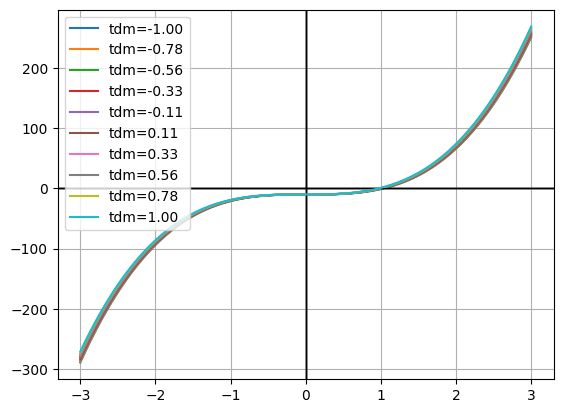

In [2]:
tdms = np.linspace(-1, 1, 10)  # Range of tdm values
pressure = 1  # Value of pressure (not used in this code, but can be incorporated if needed)

# Parameters for the cubic function
K = 10 ## Spring constant
p = 10 ## Pressure

# Generate x values for plotting
x = np.linspace(-3, 3, 1000)

# Plot the cubic function for different tdm values
for tdm in tdms:
    y = K*x**3 + tdm*x**2 - p
    plt.axhline(0, color='black', linewidth=0.8)
    plt.axvline(0, color='black', linewidth=0.8)
    plt.plot(x, y, label=f'tdm={tdm:.2f}')
    plt.grid(True)
plt.legend()
plt.show()

In [3]:
norb = 6
nelec = 6
int1e = np.zeros((norb, norb))
int2e = np.zeros((norb, norb, norb, norb))
t1 = 1.0
V = 1.2
U = 3

for i in range(norb):
    int1e[i, (i+1)%norb] = t1
    int1e[(i+1)%norb, i] = t1
    int2e[i, i, (i+1)%norb, (i+1)%norb] = V
    int2e[(i+1)%norb, (i+1)%norb, i, i] = V
    int2e[i, i, i, i] = U

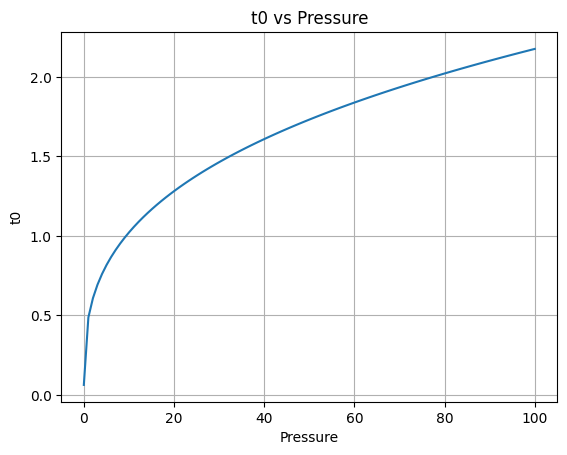

In [4]:
ph = Phonon(int1e, int2e, norb, nelec, dm_calculator)

pressure = np.linspace(0, 100, 100)

t0_list = []
for p in pressure:
    int1e_p = ph.run(pressure=p)
    t0_list.append(int1e_p[0, 1])  # Example: t0 is the hopping between site 0 and 1
    ph.clear()  # Clear the state for the next iteration

plt.plot(pressure, t0_list)
plt.xlabel("Pressure")
plt.ylabel("t0")
plt.title("t0 vs Pressure")
plt.grid()
plt.show()

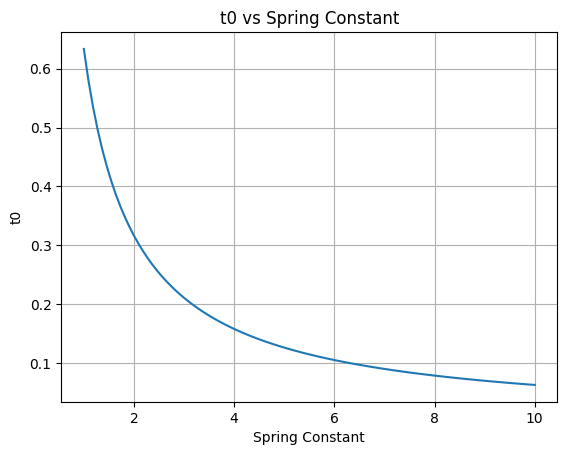

In [5]:
ph = Phonon(int1e, int2e, norb, nelec, dm_calculator)

spring = np.linspace(1, 10, 100)

t0_list = []
for s in spring:
    ph.K1 = s
    int1e_p = ph.run(pressure=0.0)  # Example: Fix pressure at the first value
    t0_list.append(int1e_p[0, 1])  # Example: t0 is the hopping between site 0 and 1
    ph.clear()  # Clear the state for the next iteration

plt.plot(spring, t0_list)
plt.xlabel("Spring Constant")
plt.ylabel("t0")
plt.title("t0 vs Spring Constant")
plt.grid()
plt.show()

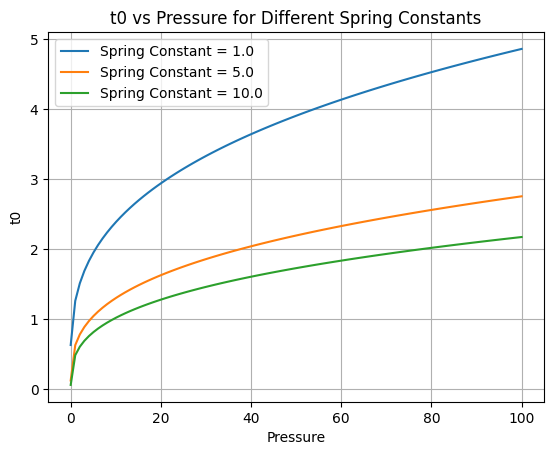

In [6]:
ph = Phonon(int1e, int2e, norb, nelec, dm_calculator)

spring = [1., 5., 10.]
pressure = np.linspace(0, 100, 100)

t0_list_0 = []
for p in pressure:
    ph.K1 = spring[0]  # Example: Fix spring constant at 5.0
    int1e_p = ph.run(pressure=p)
    t0_list_0.append(int1e_p[0, 1])  # Example: t0 is the hopping between site 0 and 1
    ph.clear()  # Clear the state for the next iteration

t0_list_1 = []
for p in pressure:
    ph.K1 = spring[1]  # Example: Fix spring constant at 5.0
    int1e_p = ph.run(pressure=p)
    t0_list_1.append(int1e_p[0, 1])  # Example: t0 is the hopping between site 0 and 1
    ph.clear()  # Clear the state for the next iteration

t0_list_2 = []
for p in pressure:
    ph.K1 = spring[2]  # Example: Fix spring constant at 5.0
    int1e_p = ph.run(pressure=p)
    t0_list_2.append(int1e_p[0, 1])  # Example: t0 is the hopping between site 0 and 1
    ph.clear()  # Clear the state for the next iteration



plt.plot(pressure, t0_list_0, label=f"Spring Constant = {spring[0]}")
plt.plot(pressure, t0_list_1, label=f"Spring Constant = {spring[1]}")
plt.plot(pressure, t0_list_2, label=f"Spring Constant = {spring[2]}")
plt.xlabel("Pressure")
plt.ylabel("t0")
plt.legend()
plt.title("t0 vs Pressure for Different Spring Constants")
plt.grid()
plt.show()